<a href="https://colab.research.google.com/github/ejr-00/lab-2-predictive-analytics/blob/main/lab_2_predictive_analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 2: Predictive Analytics with Machine Learning

**Name:** Yowome Muzzu

**Student ID:** 24432028



---

In [10]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# You will import the specific scikit-learn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42   # use this everywhere so your results are reproducible

# Dataset URLs (already provided for you)
TAXI_URL    = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/pu9kbeSaAtRZ7RxdJKX9_A/yellow-tripdata.csv"
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"

In [11]:
# Load the taxi dataset
taxi = pd.read_csv(TAXI_URL)

# Display the first five rows
display(taxi.head())

# Display the shape of the dataset
print("Dataset Shape:", taxi.shape)

# Display dataset information
print("\nDataset Information:")
taxi.info()

# Display summary statistics
print("\nSummary Statistics:")
display(taxi.describe())

# Check for missing values
print("\nMissing Values:")
display(taxi.isnull().sum())

,VendorID,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,mta_tax,tolls_amount,improvement_surcharge,tip_amount
0,2,1,17.63,2,1,132,164,1,70.0,0.5,6.94,1,16.54
1,2,1,19.52,2,1,132,236,1,70.0,0.5,6.94,1,16.19
2,2,1,17.81,2,1,132,48,1,70.0,0.5,6.94,1,12.00
3,2,2,19.30,2,1,132,148,1,70.0,0.5,0.00,1,5.00
4,2,1,18.75,2,1,132,234,1,70.0,0.5,6.94,1,10.00


Dataset Shape: (41202, 13)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41202 entries, 0 to 41201
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               41202 non-null  int64  
 1   passenger_count        41202 non-null  int64  
 2   trip_distance          41202 non-null  float64
 3   RatecodeID             41202 non-null  int64  
 4   store_and_fwd_flag     41202 non-null  int64  
 5   PULocationID           41202 non-null  int64  
 6   DOLocationID           41202 non-null  int64  
 7   payment_type           41202 non-null  int64  
 8   fare_amount            41202 non-null  float64
 9   mta_tax                41202 non-null  float64
 10  tolls_amount           41202 non-null  float64
 11  improvement_surcharge  41202 non-null  int64  
 12  tip_amount             41202 non-null  float64
dtypes: float64(5), int64(8)
memory usage: 4.1 MB

Summary Sta

,VendorID,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,mta_tax,tolls_amount,improvement_surcharge,tip_amount
count,41202.0,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000,41202.0,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000
mean,2.0,1.633926,18.384928,2.025411,0.999393,132.220475,164.546333,1.0,69.986150,0.491020,5.608198,0.999976,14.107666
std,0.0,0.924250,2.856605,0.461587,0.024625,7.726159,67.901529,0.0,6.184851,0.066404,2.979348,0.004927,5.030619
min,2.0,1.000000,0.000000,1.000000,0.000000,10.000000,3.000000,1.0,3.700000,0.000000,0.000000,0.000000,0.010000
25%,2.0,1.000000,17.370000,2.000000,1.000000,132.000000,113.000000,1.0,70.000000,0.500000,6.940000,1.000000,10.000000
50%,2.0,1.000000,18.180000,2.000000,1.000000,132.000000,163.000000,1.0,70.000000,0.500000,6.940000,1.000000,16.190000
75%,2.0,2.000000,19.380000,2.000000,1.000000,132.000000,231.000000,1.0,70.000000,0.500000,6.940000,1.000000,16.190000
max,2.0,8.000000,189.910000,5.000000,1.000000,264.000000,265.000000,1.0,199.700000,0.500000,57.000000,1.000000,98.000000



Missing Values:


,0
VendorID,0
passenger_count,0
trip_distance,0
RatecodeID,0
store_and_fwd_flag,0
PULocationID,0
DOLocationID,0
payment_type,0
fare_amount,0
mta_tax,0


Student Reasoning — Taxi data exploration What is the shape of the data? Are there missing values or impossible values (e.g. negative tips, zero-distance trips)? What does the tip_amount distribution look like (skew, outliers, many zeros)? How will this influence your preprocessing?

Answer:The taxi dataset has 41,202 rows and 13 columns. There were no missing values, but I removed rows with invalid values like zero or negative trip distances, zero fares, and negative tips. The tip_amount data is right-skewed, with many small or zero tips and a few very large tips. Because of this, I cleaned the data, created new features, and scaled the numeric features before training the model.

In [12]:
from sklearn.preprocessing import StandardScaler

# Clean the data
taxi = taxi.dropna()

taxi = taxi[
    (taxi["trip_distance"] > 0) &
    (taxi["fare_amount"] > 0) &
    (taxi["tip_amount"] >= 0)
].copy()

# Create new features
taxi["fare_per_mile"] = taxi["fare_amount"] / taxi["trip_distance"]

taxi["total_surcharges"] = (
    taxi["mta_tax"] +
    taxi["tolls_amount"] +
    taxi["improvement_surcharge"]
)

# Encode categorical columns
categorical_cols = [
    "VendorID",
    "RatecodeID",
    "payment_type",
    "store_and_fwd_flag"
]

taxi = pd.get_dummies(
    taxi,
    columns=categorical_cols,
    drop_first=True
)

# Numeric columns for scaling later
numeric_cols = [
    "passenger_count",
    "trip_distance",
    "fare_amount",
    "mta_tax",
    "tolls_amount",
    "improvement_surcharge",
    "fare_per_mile",
    "total_surcharges"
]

print("Dataset shape after preprocessing:", taxi.shape)
taxi.head()

Dataset shape after preprocessing: (41126, 15)


,passenger_count,trip_distance,PULocationID,DOLocationID,fare_amount,mta_tax,tolls_amount,improvement_surcharge,tip_amount,fare_per_mile,total_surcharges,RatecodeID_2,RatecodeID_4,RatecodeID_5,store_and_fwd_flag_1
0,1,17.63,132,164,70.0,0.5,6.94,1,16.54,3.970505,8.44,True,False,False,True
1,1,19.52,132,236,70.0,0.5,6.94,1,16.19,3.586066,8.44,True,False,False,True
2,1,17.81,132,48,70.0,0.5,6.94,1,12.00,3.930376,8.44,True,False,False,True
3,2,19.30,132,148,70.0,0.5,0.00,1,5.00,3.626943,1.50,True,False,False,True
4,1,18.75,132,234,70.0,0.5,6.94,1,10.00,3.733333,8.44,True,False,False,True


Student Reasoning — Taxi preprocessing 1. How did you handle missing/invalid rows and why? 2. Which new feature(s) did you engineer and what is the intuition behind them? 3. Which scaling method did you choose and why is it appropriate here?

Answer:
1. There were no missing values, so no imputation was required. I removed rows where the trip distance or fare amount was less than or equal to zero and removed any negative tip amounts because these values are unrealistic and could negatively affect the model's performance.

2. I created two new features: fare_per_mile and total_surcharges. The fare_per_mile feature measures how much a passenger paid per mile travelled, while total_surcharges combines all additional charges into one value. These features may provide more useful information for predicting the tip amount.

3. I used StandardScaler because it standardizes the numerical features to have a mean of 0 and a standard deviation of 1. This helps features with different scales contribute more equally during model training.

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features and target
X = taxi.drop("tip_amount", axis=1)
y = taxi["tip_amount"]

# Split into train, validation and test sets
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.4,
    random_state=RANDOM_STATE
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=RANDOM_STATE
)

# Scale the numeric columns
scaler = StandardScaler()

X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_val[numeric_cols] = scaler.transform(X_val[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

Training set: (24675, 14)
Validation set: (8225, 14)
Test set: (8226, 14)


Student Reasoning — Splitting What ratio did you use? Why is a separate validation set useful in addition to a test set? Why must the scaler (and any imputation statistics) be fit on the training data only?

Answer:
1. I used a 60% training, 20% validation, and 20% test split.

2. The validation set is used to compare different models and tune their parameters during development. The test set is only used at the end to evaluate the final model on unseen data, providing an unbiased estimate of its performance.

3. The scaler should only be fitted on the training data to prevent data leakage. If information from the validation or test sets is used during scaling, the model could gain information about unseen data, leading to overly optimistic performance results.


Linear Regression
Train  RMSE: 4.817304059029122  R²: 0.04878609473766771
Validation RMSE: 4.779463261892769  R²: 0.06890585783394498
Test RMSE: 5.223574615576836  R²: 0.040216270879033233

Decision Tree
Train  RMSE: 4.623832688898553  R²: 0.12365665236401713
Validation RMSE: 5.048184070097784  R²: -0.0387372428739956
Test RMSE: 5.541754793284964  R²: -0.08027018262844265


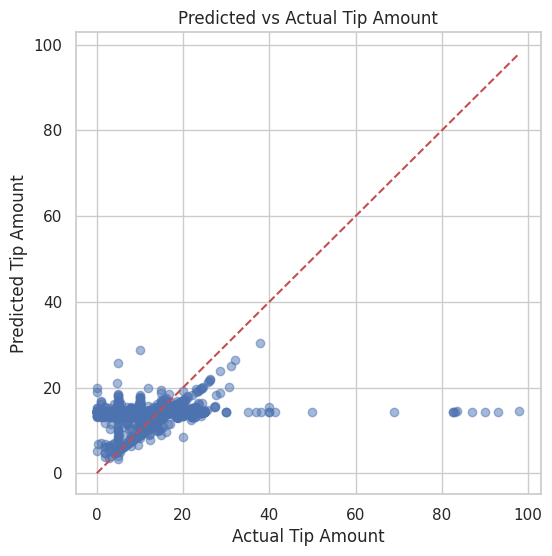

In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Train the models
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

tree_model = DecisionTreeRegressor(
    random_state=RANDOM_STATE,
    max_depth=10
)
tree_model.fit(X_train, y_train)

# Make predictions
lr_train_pred = linear_model.predict(X_train)
lr_val_pred = linear_model.predict(X_val)
lr_test_pred = linear_model.predict(X_test)

tree_train_pred = tree_model.predict(X_train)
tree_val_pred = tree_model.predict(X_val)
tree_test_pred = tree_model.predict(X_test)

# Function to print RMSE and R²
def evaluate_model(name, y_train, train_pred, y_val, val_pred, y_test, test_pred):
    print(f"\n{name}")

    print(
        "Train  RMSE:",
        mean_squared_error(y_train, train_pred) ** 0.5,
        " R²:",
        r2_score(y_train, train_pred)
    )

    print(
        "Validation RMSE:",
        mean_squared_error(y_val, val_pred) ** 0.5,
        " R²:",
        r2_score(y_val, val_pred)
    )

    print(
        "Test RMSE:",
        mean_squared_error(y_test, test_pred) ** 0.5,
        " R²:",
        r2_score(y_test, test_pred)
    )

# Evaluate both models
evaluate_model(
    "Linear Regression",
    y_train, lr_train_pred,
    y_val, lr_val_pred,
    y_test, lr_test_pred
)

evaluate_model(
    "Decision Tree",
    y_train, tree_train_pred,
    y_val, tree_val_pred,
    y_test, tree_test_pred
)

# Plot predicted vs actual values for the better model
plt.figure(figsize=(6,6))
plt.scatter(y_test, lr_test_pred, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)

plt.xlabel("Actual Tip Amount")
plt.ylabel("Predicted Tip Amount")
plt.title("Predicted vs Actual Tip Amount")

plt.show()

Student Reasoning — Regression evaluation & overfitting 1. Which model performed best on the validation set, and which hyper-parameters did you try? 2. Compare TRAIN vs VALIDATION vs TEST metrics. Is the model overfitting, underfitting, or well-fitted? Quote the specific numbers that back up your claim. 3. What would you change to reduce overfitting if you saw it?

Answer:
1. I compared Linear Regression with a Decision Tree Regressor using max_depth = 10. Linear Regression performed better on the validation set because it achieved a lower RMSE (4.78) and a higher R² (0.069) than the Decision Tree model.

2. The Linear Regression model produced similar results across all three datasets. The RMSE values were 4.82 (training), 4.78 (validation), and 5.22 (test), while the R² values were 0.049, 0.069, and 0.040 respectively. Since the performance remained consistent but the R² values were quite low, the model appears to be underfitting the data. The Decision Tree showed signs of overfitting because its training R² (0.124) was much higher than its validation (-0.039) and test (-0.080) R² values.

3. To reduce overfitting, I would simplify the model by reducing the tree depth, increasing the minimum number of samples required for a split, or collecting more training data. These changes can help the model generalize better to unseen data.

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


Dataset shape: (2111, 17)

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null  

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000



Missing values:


,0
Gender,0
Age,0
Height,0
Weight,0
family_history_with_overweight,0
FAVC,0
FCVC,0
NCP,0
CAEC,0
SMOKE,0



Class distribution:


,count
NObeyesdad,
Obesity_Type_I,351
Obesity_Type_III,324
Obesity_Type_II,297
Overweight_Level_I,290
Overweight_Level_II,290
Normal_Weight,287
Insufficient_Weight,272


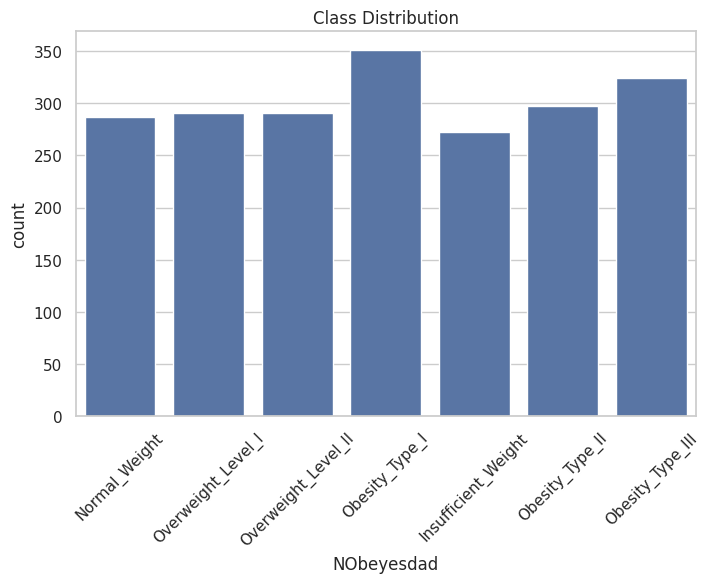

In [16]:
# Load the data
obesity = pd.read_csv(OBESITY_URL)

# Explore the data
display(obesity.head())

print("Dataset shape:", obesity.shape)

print("\nDataset information:")
obesity.info()

print("\nSummary statistics:")
display(obesity.describe())

print("\nMissing values:")
display(obesity.isnull().sum())

# Show class distribution
print("\nClass distribution:")
display(obesity["NObeyesdad"].value_counts())

plt.figure(figsize=(8,5))
sns.countplot(data=obesity, x="NObeyesdad")
plt.xticks(rotation=45)
plt.title("Class Distribution")
plt.show()

Student Reasoning — Obesity data exploration How many rows/features are there? Which columns are categorical vs numeric? Is the target balanced across the 7 classes, and why does class (im)balance matter for classification?

Answer:

1. The obesity dataset has 2,111 rows and 17 columns.
 The categorical columns include variables such as Gender, family_history_with_overweight, FAVC, CAEC, SMOKE, SCC, CALC, and MTRANS, while the remaining columns are numerical.
  The target (NObeyesdad) is fairly balanced across the seven classes, which helps the classifier learn each class more equally. If the classes were highly imbalanced, the model would become biased towards the larger classes and perform poorly on the smaller ones.

In [17]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Encode binary columns
binary_cols = [
    "family_history_with_overweight",
    "FAVC",
    "SMOKE",
    "SCC"
]

binary_map = {"yes": 1, "no": 0}

for col in binary_cols:
    obesity[col] = obesity[col].str.lower().map(binary_map)

# Create BMI
obesity["BMI"] = obesity["Weight"] / (obesity["Height"] ** 2)

# Encode categorical columns
categorical_cols = [
    "Gender",
    "CAEC",
    "CALC",
    "MTRANS"
]

obesity = pd.get_dummies(
    obesity,
    columns=categorical_cols,
    drop_first=True
)

# Encode the target
label_encoder = LabelEncoder()
obesity["NObeyesdad"] = label_encoder.fit_transform(obesity["NObeyesdad"])

# Numeric columns for scaling later
numeric_cols = [
    "Age",
    "Height",
    "Weight",
    "FCVC",
    "NCP",
    "CH2O",
    "FAF",
    "TUE",
    "BMI"
]

print("Dataset shape:", obesity.shape)
obesity.head()

Dataset shape: (2111, 25)


,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,SMOKE,CH2O,SCC,FAF,TUE,NObeyesdad,BMI,Gender_Male,CAEC_Frequently,CAEC_Sometimes,CAEC_no,CALC_Frequently,CALC_Sometimes,CALC_no,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
0,21.0,1.62,64.0,1,0,2.0,3.0,0,2.0,0,0.0,1.0,1,24.386526,False,False,True,False,False,False,True,False,False,True,False
1,21.0,1.52,56.0,1,0,3.0,3.0,1,3.0,1,3.0,0.0,1,24.238227,False,False,True,False,False,True,False,False,False,True,False
2,23.0,1.80,77.0,1,0,2.0,3.0,0,2.0,0,2.0,1.0,1,23.765432,True,False,True,False,True,False,False,False,False,True,False
3,27.0,1.80,87.0,0,0,3.0,3.0,0,2.0,0,2.0,0.0,5,26.851852,True,False,True,False,True,False,False,False,False,False,True
4,22.0,1.78,89.8,0,0,2.0,1.0,0,2.0,0,0.0,0.0,6,28.342381,True,False,True,False,False,True,False,False,False,True,False


Student Reasoning — Obesity preprocessing 1. How did you encode each type of categorical variable, and why? 2. Did you engineer any feature (e.g. BMI)? Argue whether it is fair to include given the target is an obesity level. 3. Which scaler did you use and why?

Answer:

1. I converted the binary yes/no columns into 0 and 1. I used one-hot encoding for the other categorical columns so that each category became its own feature. I encoded the target using LabelEncoder so that each obesity level became a numerical class label for classification.

2. I created a BMI feature using weight and height. BMI is closely related to obesity, so it provides useful information for the model. However, since obesity levels are largely based on BMI, including it makes the classification task easier and may give the model an advantage.

3. I used StandardScaler because it puts all numerical features on a similar scale. This helps improve model performance and prevents features with larger values from having too much influence.


In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features and target
X = obesity.drop("NObeyesdad", axis=1)
y = obesity["NObeyesdad"]

# Split into train, validation and test sets
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.4,
    stratify=y,
    random_state=RANDOM_STATE
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=RANDOM_STATE
)

# Scale the numeric columns
scaler = StandardScaler()

X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_val[numeric_cols] = scaler.transform(X_val[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

Training set: (1266, 24)
Validation set: (422, 24)
Test set: (423, 24)


Student Reasoning — Splitting What split ratio did you choose? Why is stratify=y important for this dataset? What could go wrong if you split without stratifying?

Answer:

1. I used a 60% training, 20% validation, and 20% test split.

2. Using stratify=y keeps the same class proportions in the training, validation, and test sets. This ensures that all seven obesity classes are represented in every split.

3. Without stratification, some classes could have very few or no examples in one of the datasets. This would make it harder for the model to learn those classes and could lead to unreliable evaluation results.



Logistic Regression
Train Accuracy: 0.9249605055292259  Macro F1: 0.9223621729520116
Validation Accuracy: 0.9075829383886256  Macro F1: 0.9065007959880023
Test Accuracy: 0.8841607565011821  Macro F1: 0.8784270920167307

Random Forest
Train Accuracy: 1.0  Macro F1: 1.0
Validation Accuracy: 0.985781990521327  Macro F1: 0.9855183244510716
Test Accuracy: 0.983451536643026  Macro F1: 0.9828089459803643


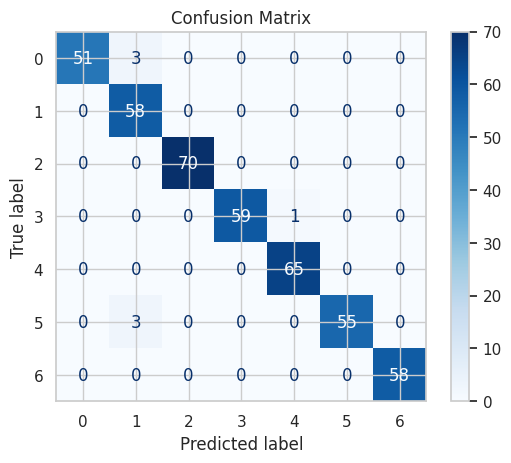

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)

# Train the classifiers
log_model = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE
)
log_model.fit(X_train, y_train)

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE
)
rf_model.fit(X_train, y_train)

# Make predictions
log_train = log_model.predict(X_train)
log_val = log_model.predict(X_val)
log_test = log_model.predict(X_test)

rf_train = rf_model.predict(X_train)
rf_val = rf_model.predict(X_val)
rf_test = rf_model.predict(X_test)

# Function to evaluate a classifier
def evaluate_classifier(name, y_train, train_pred, y_val, val_pred, y_test, test_pred):
    print(f"\n{name}")

    print(
        "Train Accuracy:", accuracy_score(y_train, train_pred),
        " Macro F1:", f1_score(y_train, train_pred, average="macro")
    )

    print(
        "Validation Accuracy:", accuracy_score(y_val, val_pred),
        " Macro F1:", f1_score(y_val, val_pred, average="macro")
    )

    print(
        "Test Accuracy:", accuracy_score(y_test, test_pred),
        " Macro F1:", f1_score(y_test, test_pred, average="macro")
    )

# Evaluate both classifiers
evaluate_classifier(
    "Logistic Regression",
    y_train, log_train,
    y_val, log_val,
    y_test, log_test
)

evaluate_classifier(
    "Random Forest",
    y_train, rf_train,
    y_val, rf_val,
    y_test, rf_test
)

# Confusion matrix for the Random Forest
ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_test,
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.show()

Student Reasoning — Classification evaluation & overfitting 1. Which classifier did you choose and why? 2. Compare TRAIN vs VALIDATION vs TEST accuracy/F1. Is the model overfitting, underfitting, or well-fitted? Cite the specific metrics. 3. From the confusion matrix, which obesity levels are hardest to tell apart, and why might that be?

Answer:

1. I compared Logistic Regression and Random Forest. Random Forest performed better because it achieved higher accuracy and macro-F1 scores on both the validation and test sets.

2. The Random Forest model achieved 100% accuracy and macro-F1 on the training set, 98.6% accuracy and macro-F1 on the validation set, and 98.3% accuracy and macro-F1 on the test set. Since the validation and test results are very close to the training results, the model generalizes well, although the perfect training score suggests a small amount of overfitting.

3. Most obesity levels were classified correctly. The few mistakes occurred between neighbouring obesity categories, which is expected because people in similar obesity levels can have very similar physical measurements and lifestyle characteristics.

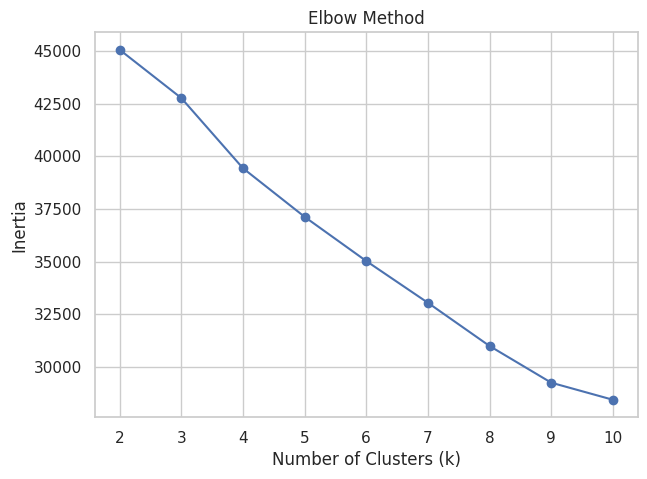

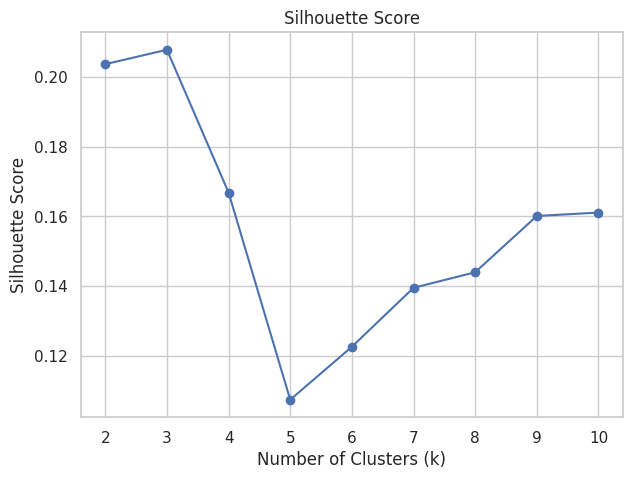

Best k: 3


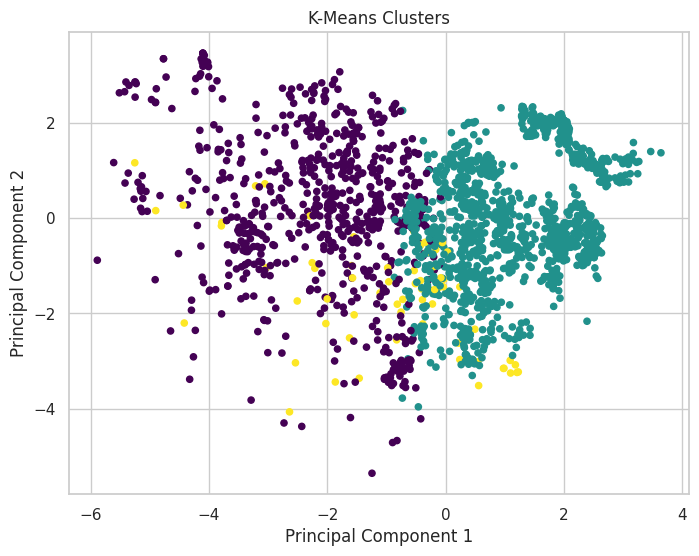

Cluster vs True Labels


NObeyesdad,0,1,2,3,4,5,6
row_0,,,,,,,
0,264,238,12,2,0,112,70
1,7,31,325,293,324,162,201
2,1,18,14,2,0,16,19


In [20]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Use only the features
X_cluster = obesity.drop("NObeyesdad", axis=1)

# Scale the features
scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)

# Find the best k
inertia = []
silhouette = []

for k in range(2, 11):
    model = KMeans(n_clusters=k, random_state=RANDOM_STATE)
    labels = model.fit_predict(X_cluster_scaled)

    inertia.append(model.inertia_)
    silhouette.append(silhouette_score(X_cluster_scaled, labels))

# Plot the Elbow curve
plt.figure(figsize=(7,5))
plt.plot(range(2,11), inertia, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.show()

# Plot the Silhouette scores
plt.figure(figsize=(7,5))
plt.plot(range(2,11), silhouette, marker="o")
plt.title("Silhouette Score")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.show()

# Choose k
best_k = silhouette.index(max(silhouette)) + 2
print("Best k:", best_k)

# Train KMeans
kmeans = KMeans(
    n_clusters=best_k,
    random_state=RANDOM_STATE
)

cluster_labels = kmeans.fit_predict(X_cluster_scaled)

# Reduce to 2D using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster_scaled)

# Plot the clusters
plt.figure(figsize=(8,6))
plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=cluster_labels,
    cmap="viridis",
    s=20
)

plt.title("K-Means Clusters")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

# Compare clusters with the true labels
crosstab = pd.crosstab(cluster_labels, obesity["NObeyesdad"])

print("Cluster vs True Labels")
display(crosstab)

Student Reasoning — Clustering 1. How did you choose k? Quote the Elbow/silhouette evidence. 2. Looking at the crosstab, do the unsupervised clusters resemble the real obesity levels? Where do they agree and where do they break down? 3. In a real public-health setting where labels are expensive to collect, what would these clusters be useful for?

Answer:

1. I used both the Elbow Method and the Silhouette Score to choose the number of clusters. The Elbow plot showed that the improvement became smaller after k = 3, and the highest silhouette score was also at k = 3 (about 0.21). Based on both methods, I chose 3 clusters.

2. The clusters show some similarity to the real obesity levels, but they do not match them perfectly. Some clusters contain mostly similar obesity levels, while others contain a mix of neighbouring classes. This is expected because K-Means groups observations based on feature similarity without using the actual class labels.

3. The clusters could help identify groups of people with similar health characteristics even when obesity labels are unavailable. Health professionals could use these groups to target screening programmes, health education, or lifestyle interventions for people with similar risk profiles.

**REFLECTION**

Supervised vs unsupervised: What did the classifier learn that K-Means could not, and vice-versa?
Regression vs classification: How did evaluating a continuous target (tips) differ from evaluating a categorical one (obesity level)?
Overfitting: Across all three tasks, where did you see the biggest train-vs-test gap, and what is the single most effective thing you did (or would do) to close it?
Answer:

1. Regression predicts a continuous value, such as the taxi tip amount. Classification predicts a category, such as the obesity level. Clustering does not use labels and instead groups similar observations based on their features.

2. The classification task produced the best results. The Random Forest classifier achieved very high accuracy and macro-F1 scores because the obesity dataset contains features that clearly relate to the target classes, making them easier to predict than the taxi tip amounts.

3. I learned that overfitting happens when a model performs very well on the training data but much worse on new data. Comparing the training, validation, and test results helped me identify whether a model was generalizing well or memorizing the training data.

4. If I did this lab again, I would experiment with more features and compare more algorithms before choosing the final model. This would help me understand which model works best for each dataset.